# Problem 1
## 1.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy import stats
import numpy as np

data = pd.read_csv("./data/passengercarmileage.txt", sep="\t", index_col=0)
data

,VOL,HP,MPG,SP,WT
makeAndModel,,,,,
GM/GeoMetroXF1,89,49,65.4,96,17.5
GM/GeoMetro,92,55,56.0,97,20.0
GM/GeoMetroLSI,92,55,55.9,97,20.0
SuzukiSwift,92,70,49.0,105,20.0
DaihatsuCharade,92,53,46.5,96,20.0
...,...,...,...,...,...
Mercedes500SL,50,322,18.1,165,45.0
Mercedes560SEL,115,238,17.2,140,45.0
JaguarXJSConvert,50,263,17.0,147,45.0


                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.624
Model:                            OLS   Adj. R-squared:                  0.619
Method:                 Least Squares   F-statistic:                     132.7
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           1.15e-18
Time:                        00:12:47   Log-Likelihood:                -264.61
No. Observations:                  82   AIC:                             533.2
Df Residuals:                      80   BIC:                             538.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     50.0661      1.569     31.900      0.0

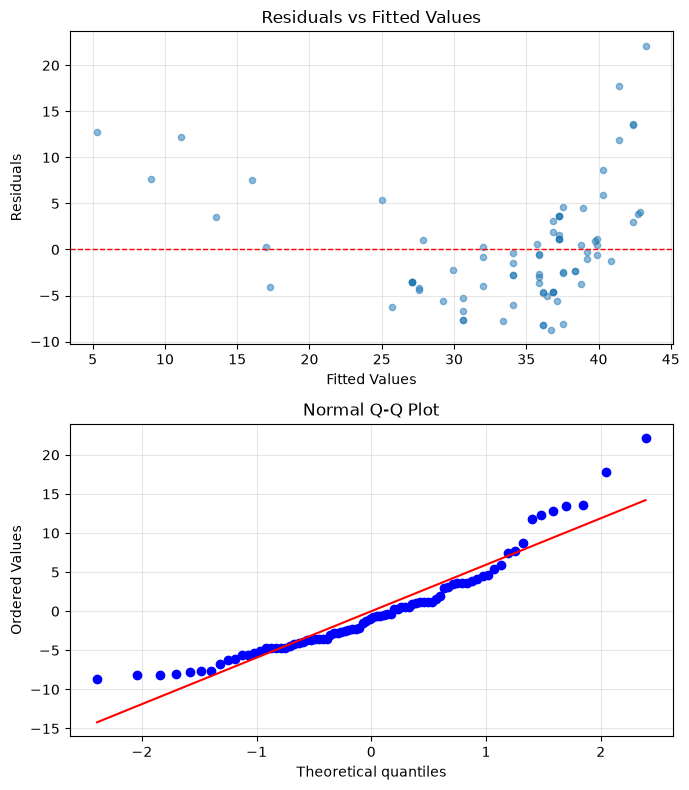

In [27]:
model = smf.ols("MPG ~ HP", data=data)
results = model.fit()
print(results.summary())
residuals = results.resid
fitted = results.fittedvalues

# Create diagnostic plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

# Get residuals and fitted values
residuals = results.resid
fitted = results.fittedvalues

# Plot 1: Residuals vs Fitted Values
ax1.scatter(fitted, residuals, alpha=0.5, s=20)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2.


                            OLS Regression Results                            
Dep. Variable:                log_MPG   R-squared:                       0.734
Model:                            OLS   Adj. R-squared:                  0.731
Method:                 Least Squares   F-statistic:                     221.2
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           9.62e-25
Time:                        00:13:05   Log-Likelihood:                 36.047
No. Observations:                  82   AIC:                            -68.09
Df Residuals:                      80   BIC:                            -63.28
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      4.0132      0.040    100.021      0.0

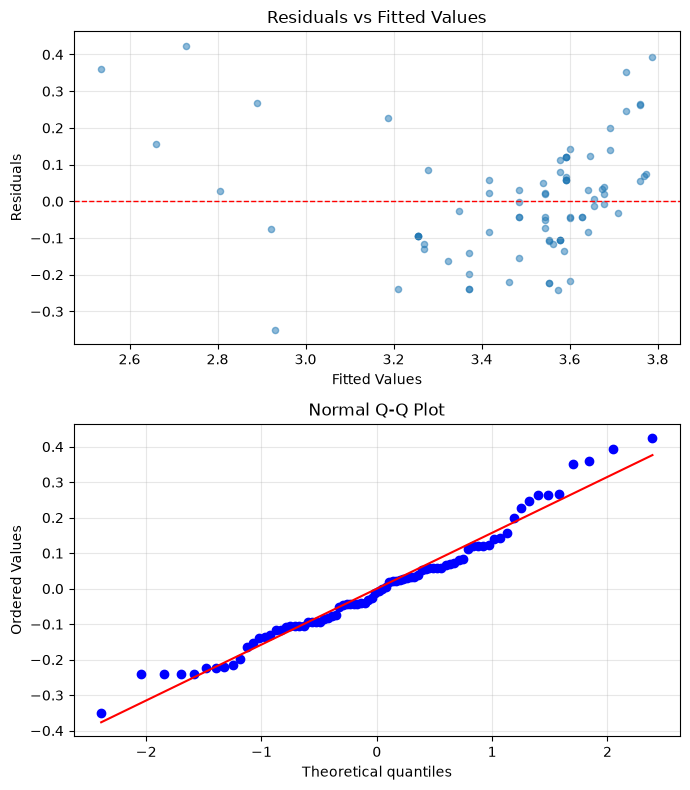

In [28]:
data["log_MPG"] = np.log(data["MPG"])
model = smf.ols("log_MPG ~ HP", data=data)
results = model.fit()
print(results.summary())
residuals = results.resid
fitted = results.fittedvalues

# Create diagnostic plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

# Get residuals and fitted values
residuals = results.resid
fitted = results.fittedvalues

# Plot 1: Residuals vs Fitted Values
ax1.scatter(fitted, residuals, alpha=0.5, s=20)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.

                            OLS Regression Results                            
Dep. Variable:                    MPG   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.867
Method:                 Least Squares   F-statistic:                     132.7
Date:                Mon, 05 Oct 2026   Prob (F-statistic):           9.98e-34
Time:                        00:15:52   Log-Likelihood:                -220.00
No. Observations:                  82   AIC:                             450.0
Df Residuals:                      77   BIC:                             462.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    192.4378     23.532      8.178      0.0

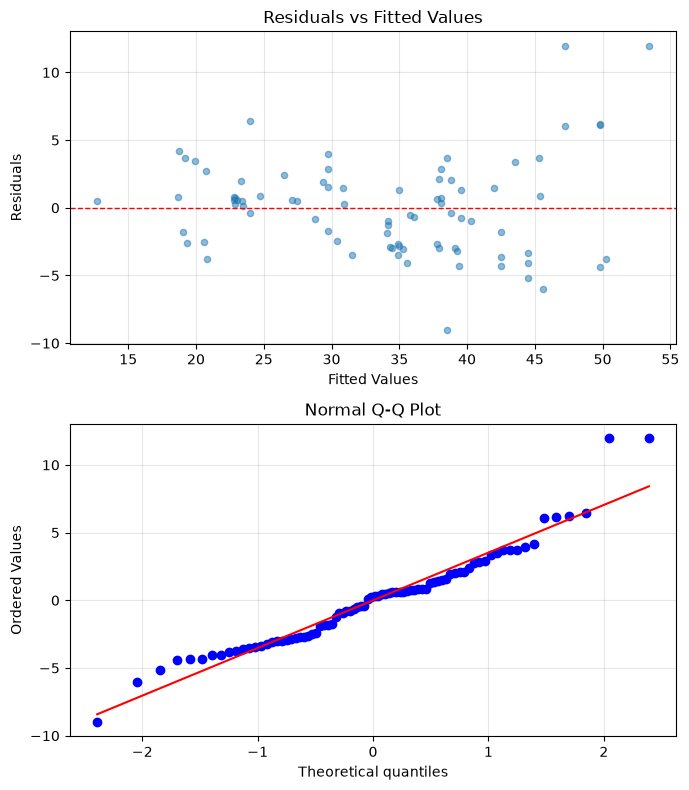

In [29]:
model = smf.ols("MPG ~ HP + VOL + SP + WT", data=data)
results = model.fit()
print(results.summary())
residuals = results.resid
fitted = results.fittedvalues

# Create diagnostic plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8))

# Get residuals and fitted values
residuals = results.resid
fitted = results.fittedvalues

# Plot 1: Residuals vs Fitted Values
ax1.scatter(fitted, residuals, alpha=0.5, s=20)
ax1.axhline(y=0, color='r', linestyle='--', linewidth=1)
ax1.set_xlabel('Fitted Values')
ax1.set_ylabel('Residuals')
ax1.set_title('Residuals vs Fitted Values')
ax1.grid(True, alpha=0.3)

# Plot 2: Q-Q plot for normality check
stats.probplot(residuals, dist="norm", plot=ax2)
ax2.set_title('Normal Q-Q Plot')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Problem 2
## 1.

We have $Y_i = \beta X_i  + \epsilon_i$, where $\epsilon_i$ are i.i.d. and $X_i,\dots,X_n$, $Y_i,\dots,Y_n$. We want to minimize the residual sum of squares
$$
\text{RSS}=\sum_{i=1}^n \hat{\epsilon}_i^2 = \sum_{i=1}^n (Y_i - \hat{\beta}X_i)^2.
$$
Taking the derivative w.r.t. $\hat{\beta}$ and setting it to zero, we find
$$
\begin{align*}
\frac{\partial \text{RSS}}{\partial \hat{\beta}} &= -2 \sum_{i=1}^n X_i(Y_i - \hat{\beta}X_i) = 0 \\
\implies \sum_{i=1}^n X_i Y_i &= \hat{\beta}\sum_{i=1}^n X_i^2 \\
\implies \hat{\beta} &= \frac{\sum_{i=1}^n X_i Y_i}{\sum_{i=1}^n X_i^2}.
\end{align*}
$$

## 2.
Substitute the equation for $Y_i$ into the least squares estimate
$$
\begin{align*}
\hat{\beta} &= \frac{\sum_{i=1}^n X_i Y_i}{\sum_{i=1}^n X_i^2} \\
&= \frac{\sum_{i=1}^n X_i (\beta X_i + \epsilon_i)}{\sum_{i=1}^n X_i^2} \\
&= \beta\frac{\sum_{i=1}^n X_i^2}{\sum_{i=1}^n X_i^2} + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2} \\
&= \beta + \frac{\sum_{i=1}^n X_i \epsilon_i}{\sum_{i=1}^n X_i^2}.
\end{align*}
$$
Since $\mathbb{E}(X_i\epsilon_i)=0$, the second term vanishes when we take the expectation $\mathbb{E}(\hat{\beta})$, and thus $\mathbb{E}(\hat{\beta})=\beta$, i.e. the estimator is unbiased.